In [1]:
import numpy as np
import h5py
import importlib

from gtda.plotting import plot_point_cloud


from pathlib import Path

# Визуализация

In [2]:
samples = {}
train_file = "./data/MNIST3d/train_point_clouds.h5"

with h5py.File(train_file,"r") as hf:
  for key in hf.keys(): # key = id
    group = hf[key]
    label = int(group.attrs["label"])

    if (label not in samples):  # take 1 instance of each digit
      points = group["points"][:] # (N, 3)  x, y, z
      samples[label] = points

      if len(samples) == 10:
        break


In [3]:
# sorting is optional i just think it looks better this way
sorted_samples = dict(sorted(samples.items()))
plot_point_cloud(sorted_samples[8]) # change number in brackets to plot different digits

Точки в облаках расположены достаточно плотно. Внутри цифры полые.

# Нормализация
Согласно документации датасета, все облака точек должны быть нормализованы. Проверим это, собрав статистику по каждой цифре отдельно и по всем цифрам сразу.

In [7]:
import utils.stat
importlib.reload(utils.stat)

class_stats, global_stats = utils.stat.compute_statistics(train_file)

In [8]:
class_stats

num_points                                      range_x        range_y  \
      num_clouds        mean        std    min    max    mean    std    mean   
label                                                                          
0            479  27806.3674  2404.0861  19050  35400  0.3000  0.000  0.9065   
1            563  13510.6572  2211.8518   9250  26850  0.3000  0.000  0.4898   
2            488  24701.2295  3273.3208  14600  32400  0.3000  0.000  0.9172   
3            493  25364.5030  3462.8836  14550  33550  0.3000  0.000  0.8404   
4            535  21927.7570  2667.0957  14950  28300  0.3000  0.000  0.8257   
5            434  24189.2857  3614.6889  15900  35600  0.3000  0.000  0.9144   
6            501  22882.1357  3531.0587  14450  37300  0.3000  0.000  0.7500   
7            550  20357.0909  2637.8022  13150  27600  0.3001  0.001  0.8112   
8            462  25543.9394  3563.1286  15250  38200  0.3000  0.000  0.7985   
9            495  21867.9798  2837.9709  12100  30600  0.3000  0.000  0.7201   

              range_z          
          std    mean     std  
label                          
0      0.1138  0.9827  0.0532  
1      0.2016  0.9996  0.0087  
2      0.1172  0.9553  0.0883  
3      0.1393  0.9941  0.0288  
4      0.1400  0.9942  0.0266  
5      0.1223  0.9461  0.0928  
6      0.1477  0.9954  0.0284  
7      0.1433  0.9916  0.0366  
8      0.1462  0.9936  0.0342  
9      0.1336  0.9986  0.0126

Наиболее заметное различие наблюдается в количестве точек: цифры 0 и 8 представлены наиболее плотными облаками, в то время как цифра 1 содержит существенно меньше точек.
По пространственным характеристикам все объекты имеют практически идентичный диапазон по оси X, что обусловлено особенностями генерации датасета. В то же время по осям Y и Z наблюдаются выраженные класс-специфичные различия. Цифра 1 характеризуется вытянутостью (относительно узкий диапазон по Y), в то время как цифры 0, 2 и 5 имеют более сбалансированные пропорции. Классы демонстрируют диапазон по Z близкий к 1.0.

In [9]:
global_stats

,mean,std,min,max
num_points,22600.0900,4895.4854,9250.00,38200.0000
range_x,0.3000,0.0003,0.30,0.3158
range_y,0.7915,0.1899,0.15,1.0000
range_z,0.9859,0.0509,0.50,1.0000
label,4.4670,2.8722,0.00,9.0000


# Сэмплирование

In [4]:
import utils.subsampling
importlib.reload(utils.subsampling)

<module 'utils.subsampling' from 'c:\\Users\\zhilk\\vscode projects\\topology-mnist3d\\utils\\subsampling.py'>

In [ ]:
point_clouds, labels = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=50)

Облака содержат очень много точек. Симплициальные комплексы долго считаются и могут не влезать в память. Попробуем сэмплировать точки.

In [31]:
import utils.subsampling
importlib.reload(utils.subsampling)

to_subsample, labels_subsampled = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=100)
subsampled_point_clouds = utils.subsampling.subsample_point_clouds(to_subsample, 5000)

plot_point_cloud(subsampled_point_clouds[0])

# Симплициальные комплексы и диаграммы персистентности

## Альфа комплекс

Альфа-комплекс представляет собой симплициальный комплекс, предназначенный для анализа топологической структуры облаков точек. Его построение основано на геометрическом расположении точек в пространстве и позволяет выявлять связные компоненты, циклы и полости, сохраняя при этом форму исходного объекта.

Альфа-комплекс использует информацию о взаимном расположении точек и формируется на основе триангуляции Делоне. Благодаря этому в комплекс включаются только геометрически обоснованные элементы, что существенно снижает их общее количество и уменьшает вычислительную сложность.

По мере увеличения параметра фильтрации альфа-комплекс постепенно расширяется: отдельные точки объединяются в связные компоненты, возникают и исчезают циклы, а также могут формироваться трёхмерные полости. Наблюдение за изменением топологических характеристик на различных уровнях фильтрации позволяет определить наиболее устойчивые особенности объекта и отделить значимые структуры от шумовых артефактов.

Для облаков точек, представляющих трёхмерные изображения цифр, альфа-комплекс позволяет эффективно сохранять информацию о форме объектов и выявлять различия между классами, связанные с наличием отверстий, замкнутых контуров и особенностями пространственной геометрии.

In [54]:
import utils.persistence
importlib.reload(utils.persistence)

_, diagrams = utils.persistence.build_diagrams(point_clouds)

Processing clouds: 100%|██████████| 10/10 [00:00<00:00, 3970.00it/s]


In [ ]:
import utils.persistence
importlib.reload(utils.persistence)

_, diagrams_sub = utils.persistence.build_diagrams(subsampled_point_clouds)

Processing clouds: 100%|██████████| 10/10 [00:00<00:00, 4864.65it/s]


### Сохранение и загрузка диаграмм

In [12]:
trees_path = Path("./data/tda/simplex_trees_gudhi.pkl")
diagrams_path = Path("./data/tda/persistence_diagrams_gudhi.pkl")

subsampled_trees_path = Path("./data/tda/subsampled_simplex_trees_gudhi.pkl")
subsampled_diagrams_path = Path("./data/tda/subsampled_persistence_diagrams_gudhi.pkl")

In [208]:
import utils.save_load
importlib.reload(utils.save_load)

#utils.save_load.save_tree_diagram(diagrams_path, diagrams, trees_path, trees)
utils.save_load.save_tree_diagram(subsampled_diagrams_path, diagrams_sub, subsampled_trees_path, trees_sub)

Trees saved to data\tda\subsampled_simplex_trees_gudhi.pkl
Diagrams saved to data\tda\subsampled_persistence_diagrams_gudhi.pkl


In [13]:
import utils.save_load
importlib.reload(utils.save_load)

diagrams_loaded = utils.save_load.load_object(diagrams_path)
subsampled_diagrams_loaded = utils.save_load.load_object(subsampled_diagrams_path)

Loaded 500 objects
Loaded 1000 objects


### Отрисовка диаграмм

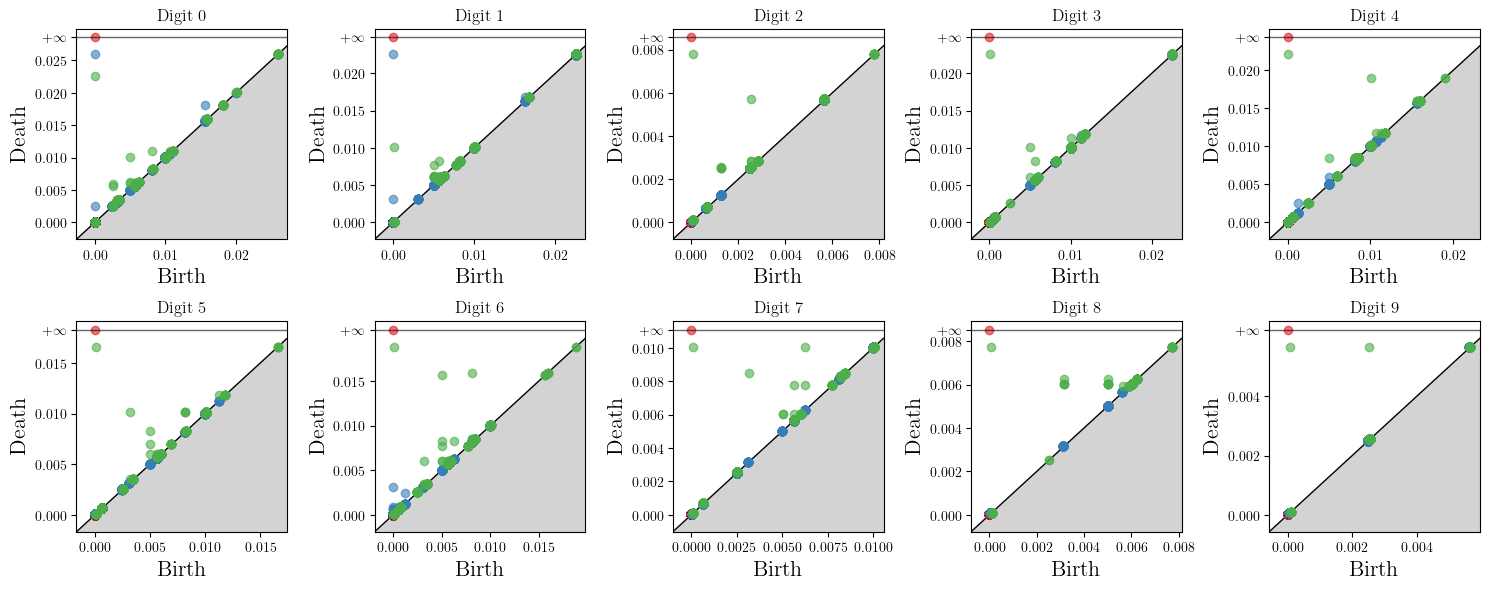

In [56]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_all_digits(diagrams_loaded, labels)

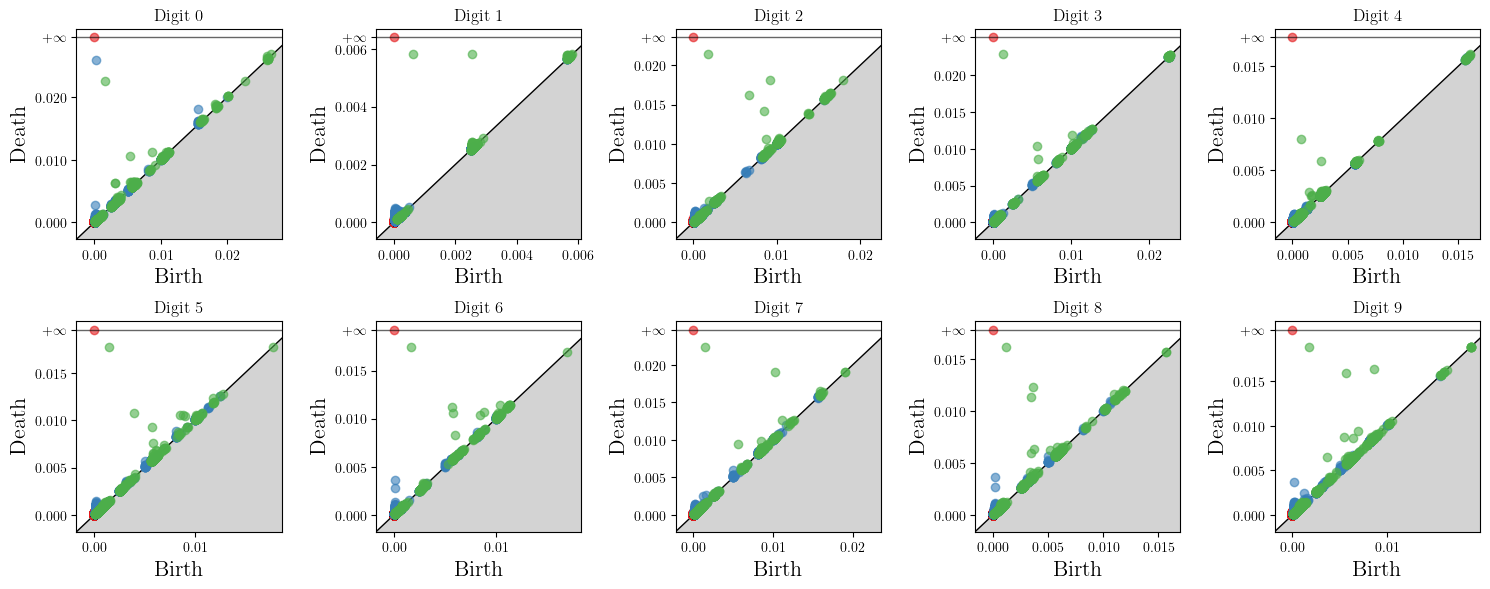

In [37]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_all_digits(subsampled_diagrams_loaded, labels)

#### По цифрам

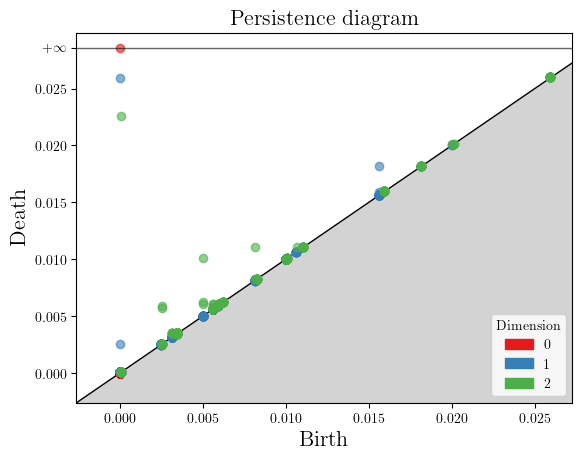

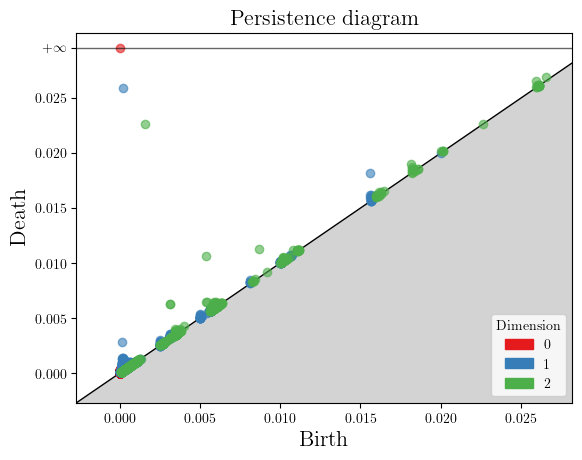

In [38]:
import utils.plot
importlib.reload(utils.plot)

digit = 0
utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

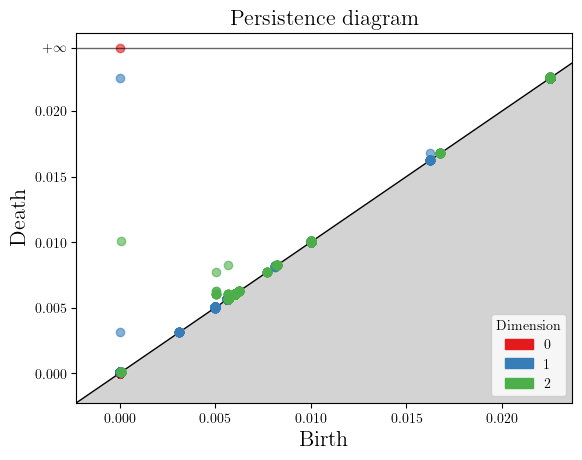

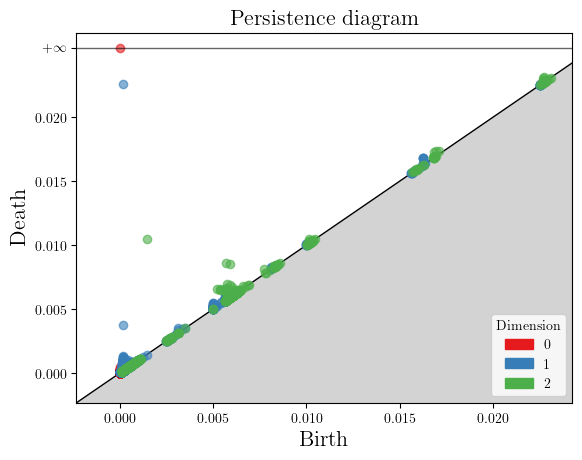

In [39]:
import utils.plot
importlib.reload(utils.plot)

digit = 1

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

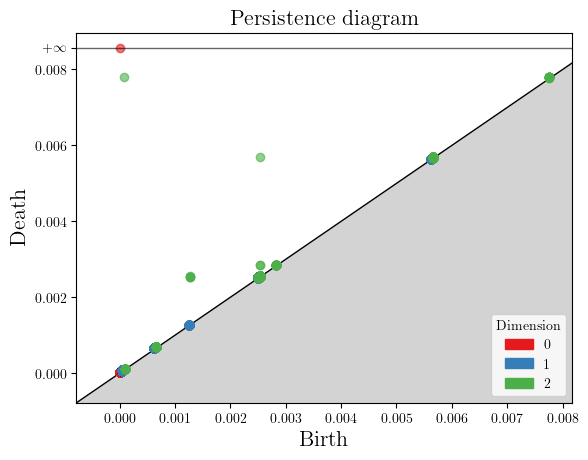

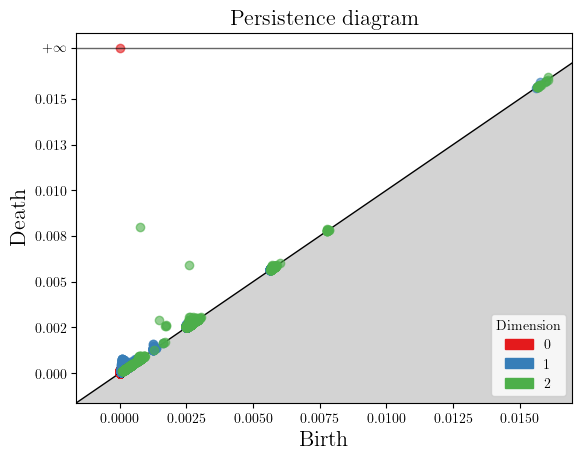

In [40]:
import utils.plot
importlib.reload(utils.plot)

digit = 2

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

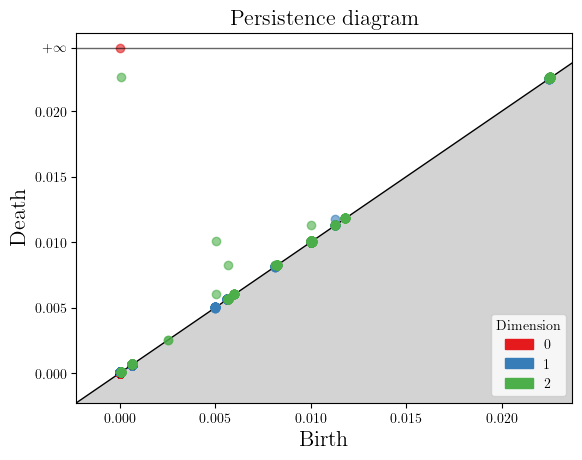

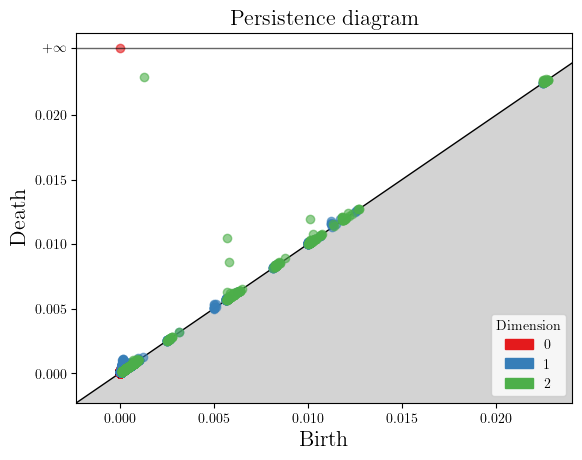

In [41]:
import utils.plot
importlib.reload(utils.plot)

digit = 3

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

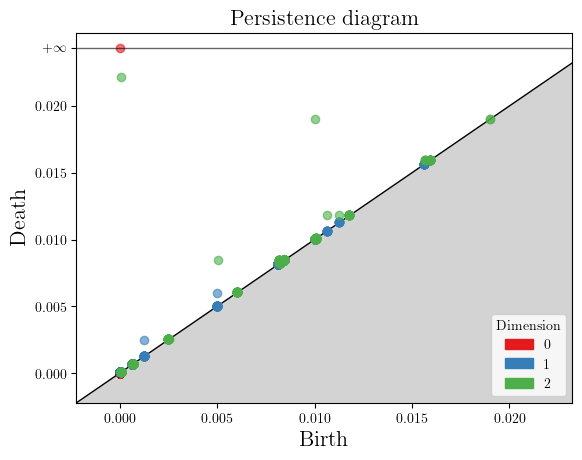

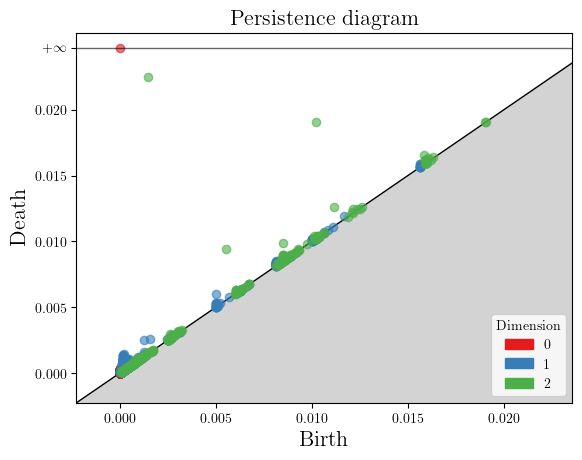

In [42]:
import utils.plot
importlib.reload(utils.plot)

digit = 4

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

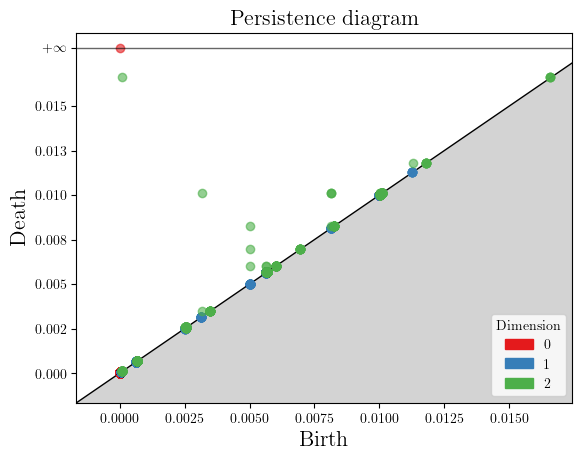

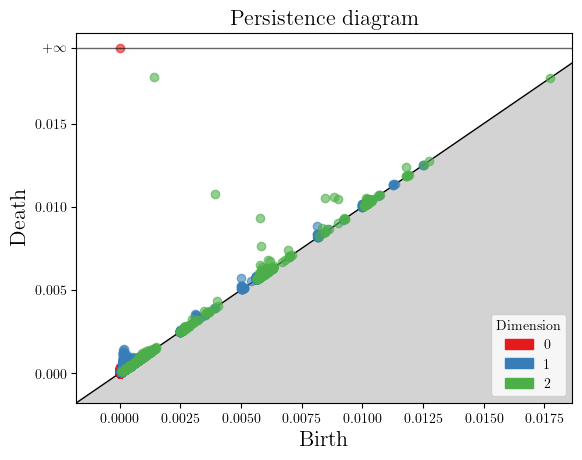

In [43]:
import utils.plot
importlib.reload(utils.plot)

digit = 5

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

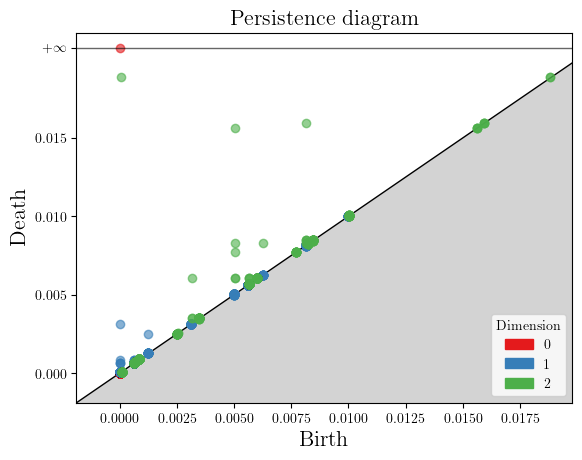

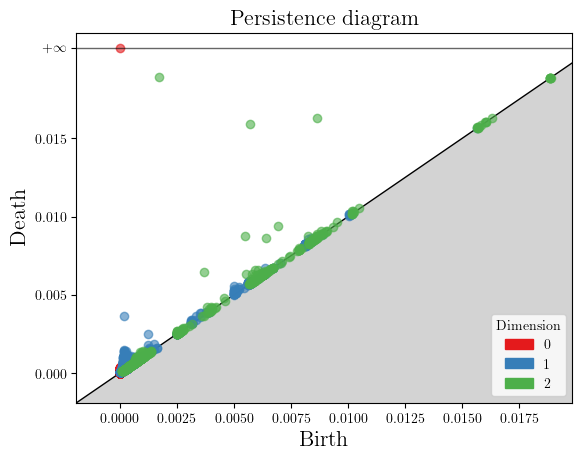

In [44]:
import utils.plot
importlib.reload(utils.plot)

digit = 6

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

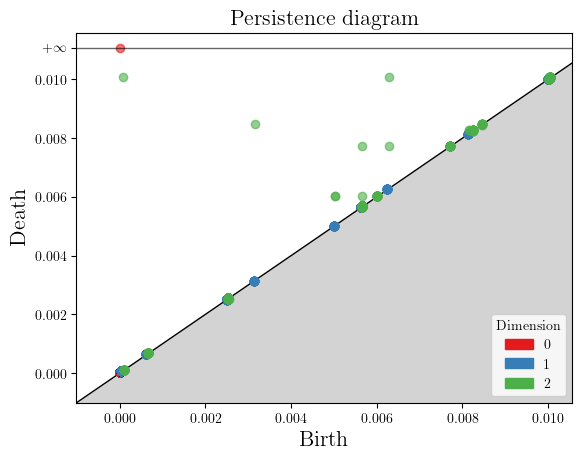

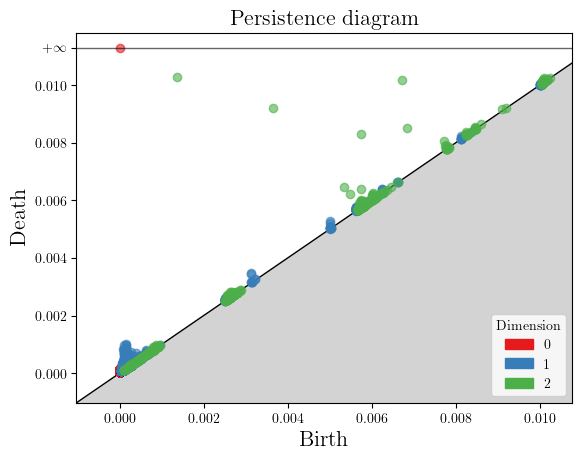

In [45]:
import utils.plot
importlib.reload(utils.plot)

digit = 7

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

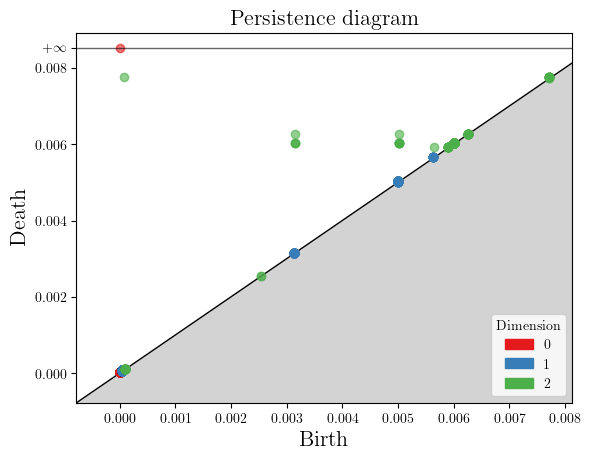

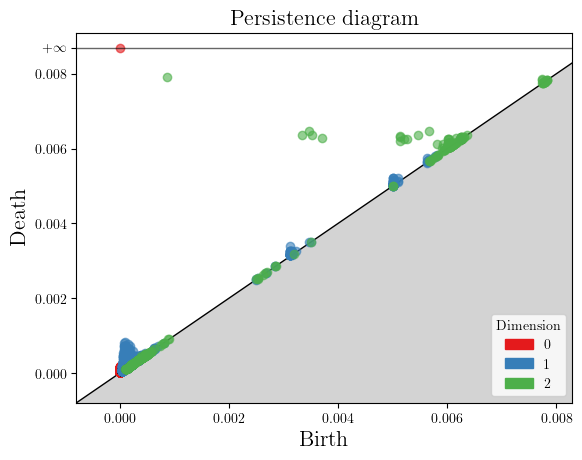

In [46]:
import utils.plot
importlib.reload(utils.plot)

digit = 8

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

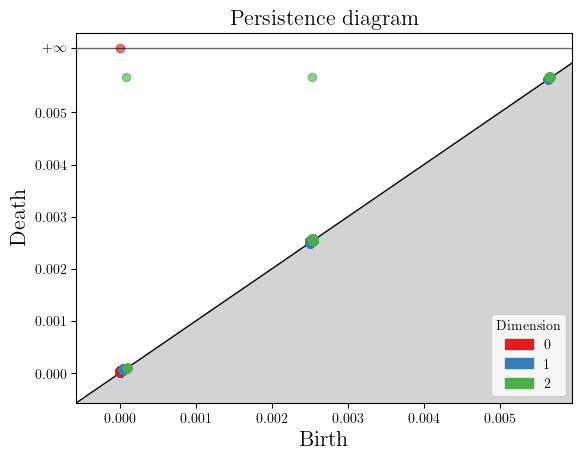

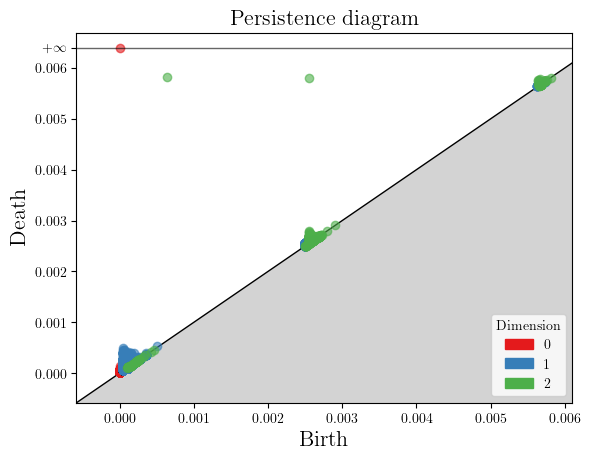

In [47]:
import utils.plot
importlib.reload(utils.plot)

digit = 9

utils.plot.plot_persistence(diagrams_loaded, labels, digit)
utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, digit)

# Векторизация

После построения диаграмм персистентности возникает задача их использования в алгоритмах машинного обучения. Диаграммы не могут быть напрямую поданы на вход большинству методов классификации и регрессии. Для решения этой проблемы применяются методы векторизации, преобразующие диаграмму персистентности в вектор фиксированной длины.

Одним из наиболее распространённых способов векторизации являются ландшафты персистентности (Persistence Landscapes). Для каждой точки диаграммы строится функция, отражающая время существования соответствующего топологического признака. Затем для каждого значения параметра фильтрации выбираются наибольшие значения этих функций, образующие набор уровней ландшафта. Полученные функции дискретизируются на равномерной сетке и преобразуются в числовой вектор фиксированной размерности.

In [14]:
from tqdm import tqdm

# переводим в gtda формат
diagrams_sub_gtda = [
    np.array([
        [birth, death, dim]
        for dim, (birth, death) in diag
    ])
    for diag in tqdm(subsampled_diagrams_loaded)
]

100%|██████████| 1000/1000 [00:59<00:00, 16.73it/s]


In [16]:
def top_k(diag, k=50):
    """
    Принимает диаграмму персистентности и оставляет k лучших (наиболее далеких от диагонали) точек.
    """
    pers = diag[:, 1] - diag[:, 0]  # death - birth
    idx = np.argsort(pers)[::-1][:k]    # индексы самых устойчивых объектов
    return diag[idx]

X_h1_top = [top_k(d[d[:, 2] == 1], k=50)    # только h1
            for d in diagrams_sub_gtda]

X = np.stack(X_h1_top)

Параметр n_layers определяет количество уровней ландшафта, используемых для описания диаграммы персистентности. Первый уровень отражает наиболее выраженные топологические признаки, а последующие уровни учитывают менее значимые структуры, позволяя сохранить больше информации о форме объекта. Параметр n_bins задаёт число точек дискретизации по оси фильтрации, то есть разрешение, с которым непрерывные функции ландшафта преобразуются в числовое представление. Увеличение n_bins позволяет более точно описывать форму ландшафта, однако приводит к росту размерности признакового пространства и вычислительных затрат.

In [17]:
from gtda.diagrams import PersistenceLandscape

PL = PersistenceLandscape(n_layers=5, n_bins=300, n_jobs=-1)
landscapes = PL.fit_transform(X)

In [48]:
idx = np.where(labels_subsampled == 0)[0][0]
PL.plot(landscapes, sample=idx)

4000
(4000, 1500)
Accuracy =  0.53
F1 score =  0.5273148974972944
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        50
           1       0.84      0.92      0.88        50
           2       0.37      0.32      0.34        50
           3       0.47      0.44      0.45        50
           4       0.28      0.30      0.29        50
           5       0.31      0.26      0.28        50
           6       0.46      0.38      0.42        50
           7       0.37      0.46      0.41        50
           8       0.85      0.68      0.76        50
           9       0.53      0.68      0.60        50

    accuracy                           0.53       500
   macro avg       0.53      0.53      0.53       500
weighted avg       0.53      0.53      0.53       500

[[43  0  0  0  0  1  0  0  1  5]
 [ 0 46  0  0  0  0  0  4  0  0]
 [ 0  0 16  5  9  3  4  9  2  2]
 [ 1  1  5 22  5  6  2  7  0  1]
 [ 0  0  5  5 15  9  3 12  0  1]
 [ 1  0  7

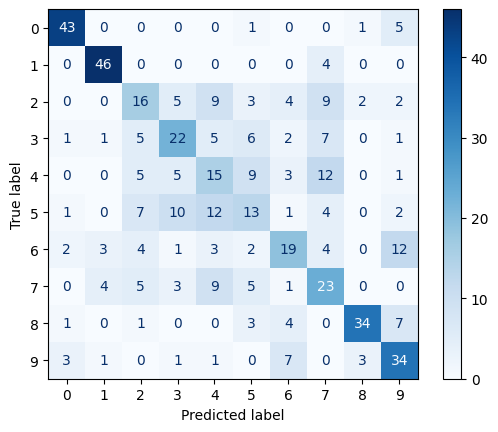

In [245]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Y = labels_subsampled
print(Y.shape[0])
s = Y.shape[0]

X_squeezed = np.reshape(landscapes, (Y.shape[0],-1))
print(X_squeezed.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_squeezed,
    Y,
    test_size=1/8,
    random_state=42,
    stratify=Y
)

#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

clf = HistGradientBoostingClassifier(
	#max_iter=5000,
    #oob_score=True,
    random_state=42,
	#n_jobs=-1
)

clf.fit(X_train, y_train)

#print(f"OOB score: {clf.oob_score_:.3f}")

y_test_pred = clf.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_test_pred))
print("F1 score = ", f1_score(y_test, y_test_pred, average="macro"))
print(classification_report(y_test,y_test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap=plt.cm.Blues)
print(disp.confusion_matrix)
	
plt.show()

## Комплекс Вьеториса-Рипса

Плохо масштабируется, количество симплексов растет экспоненциально. Не посчитался за разумное время

In [10]:
from gtda.homology import VietorisRipsPersistence

homology_dimensions = [0, 1, 2]

persistence = VietorisRipsPersistence(
    homology_dimensions=homology_dimensions,
    n_jobs=-1
)

In [ ]:
diagrams = persistence.fit_transform(subsampled_point_clouds)